# Step 9: Fine-tune DINOv2-Large + UperNet (Coarse 6-class)

Thin orchestration notebook for Databricks. All reusable logic lives in
`histological_image_analysis.training` (installed as a wheel on the cluster).

**Phase 1:** Coarse 6-class segmentation on 10µm Nissl CCFv3 data,
frozen DINOv2-Large backbone, UperNet head-only training.

In [0]:
# Cell 0 — Install project wheel from DBFS
# The wheel is uploaded by `make deploy-wheel` and contains all reusable
# training pipeline code (ontology, slicer, dataset, training modules).

%pip install /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
dbutils.library.restartPython()

Processing /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
histological-image-analysis is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Cell 1 — Configuration
# All environment-specific paths and hyperparameters live here.

import os
import mlflow

# ---------- MLflow setup ----------
os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"

EXPERIMENT_NAME = "/Users/noel.nosse@grainger.com/histology-brain-segmentation"
try:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
except Exception:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
mlflow.set_experiment(experiment_id=experiment_id)
print(f"MLflow experiment: {EXPERIMENT_NAME} (ID: {experiment_id})")

# ---------- Databricks paths ----------
WORKSPACE_BASE = "/Workspace/Users/noel.nosse@grainger.com/visual-model-ft/histology"
ONTOLOGY_PATH = f"{WORKSPACE_BASE}/ontology/structure_graph_1.json"
ANNOTATION_10_PATH = f"{WORKSPACE_BASE}/ccfv3/annotation_10.nrrd"
ANNOTATION_25_PATH = f"{WORKSPACE_BASE}/ccfv3/annotation_25.nrrd"
TEMPLATE_25_PATH = f"{WORKSPACE_BASE}/ccfv3/average_template_25.nrrd"
# ara_nissl_10.nrrd exceeds workspace limit — lives on DBFS
NISSL_10_PATH = "/dbfs/FileStore/allen_brain_data/ccfv3/ara_nissl_10.nrrd"

# ---------- JFrog / HuggingFace model ----------
HF_ENDPOINT = os.environ.get(
    "HF_ENDPOINT",
    "https://graingerreadonly.jfrog.io/artifactory/api/huggingfaceml/huggingfaceml-remote",
)
MODEL_REPO_ID = "facebook/dinov2-large"
MODEL_CACHE_DIR = "/tmp/dinov2-large"

# ---------- Training hyperparameters ----------
HYPERPARAMS = {
    "num_labels": 6,  # Coarse: Cerebrum, BS, CB, Fiber, VS, Background
    "crop_size": 518,  # DINOv2 native resolution
    "batch_size": 8,
    "learning_rate": 1e-4,
    "num_epochs": 50,
    "freeze_backbone": True,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "model": MODEL_REPO_ID,
    "dataset": "CCFv3 ara_nissl_10",
}

# Unpack for convenience
NUM_LABELS = HYPERPARAMS["num_labels"]
CROP_SIZE = HYPERPARAMS["crop_size"]
BATCH_SIZE = HYPERPARAMS["batch_size"]
LEARNING_RATE = HYPERPARAMS["learning_rate"]
NUM_EPOCHS = HYPERPARAMS["num_epochs"]
FREEZE_BACKBONE = HYPERPARAMS["freeze_backbone"]

# ---------- Output ----------
# Checkpoints on local disk — Workspace has 500 MB per-file limit,
# DINOv2-Large + UperNet is ~1.2 GB in safetensors format.
OUTPUT_DIR = "/tmp/checkpoints/coarse_6class"
# Final model on DBFS — persistent across cluster restarts, no size limit.
FINAL_MODEL_DIR = "/dbfs/FileStore/allen_brain_data/models/coarse_6class"

print(f"Ontology:       {ONTOLOGY_PATH}")
print(f"Nissl 10µm:     {NISSL_10_PATH}")
print(f"HF endpoint:    {HF_ENDPOINT}")
print(f"Num labels:     {NUM_LABELS}")
print(f"Checkpoints:    {OUTPUT_DIR}")
print(f"Final model:    {FINAL_MODEL_DIR}")

MLflow experiment: /Users/noel.nosse@grainger.com/histology-brain-segmentation (ID: 1345391216675532)
Ontology:       /Workspace/Users/noel.nosse@grainger.com/visual-model-ft/histology/ontology/structure_graph_1.json
Nissl 10µm:     /dbfs/FileStore/allen_brain_data/ccfv3/ara_nissl_10.nrrd
HF endpoint:    https://graingerreadonly.jfrog.io/artifactory/api/huggingfaceml/huggingfaceml-remote
Num labels:     6
Checkpoints:    /tmp/checkpoints/coarse_6class
Final model:    /dbfs/FileStore/allen_brain_data/models/coarse_6class


In [0]:
# Cell 2 — Download model weights from JFrog Artifactory mirror
#
# Uses retry pattern per LESSONS_LEARNED.md — Artifactory can drop connections.
# etag_timeout=86400 avoids unnecessary HEAD requests.

import time
from huggingface_hub import snapshot_download

print(f"Downloading {MODEL_REPO_ID} from Artifactory...")
for attempt in range(1, 4):
    try:
        model_path = snapshot_download(
            repo_id=MODEL_REPO_ID,
            endpoint=HF_ENDPOINT,
            etag_timeout=86400,
            cache_dir=MODEL_CACHE_DIR,
        )
        break
    except Exception as e:
        if attempt < 3:
            wait = 2 ** attempt
            print(f"  Attempt {attempt} failed ({e.__class__.__name__}), retrying in {wait}s...")
            time.sleep(wait)
        else:
            raise

print(f"Model downloaded to: {model_path}")

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Model downloaded to: /tmp/dinov2-large/models--facebook--dinov2-large/snapshots/a18992645e496e6d21ea90829a6652ed6f75ec47


In [0]:
# Cell 3 — Build training and validation datasets
#
# Pipeline: OntologyMapper → CCFv3Slicer → BrainSegmentationDataset

from histological_image_analysis.ontology import OntologyMapper
from histological_image_analysis.ccfv3_slicer import CCFv3Slicer
from histological_image_analysis.dataset import BrainSegmentationDataset

# 1. Load ontology and build coarse mapping
mapper = OntologyMapper(ONTOLOGY_PATH)
coarse_mapping = mapper.build_coarse_mapping()
class_names = mapper.get_class_names(coarse_mapping)
print(f"Coarse classes ({len(class_names)}): {class_names}")

# 2. Load CCFv3 volumes (10\u00b5m Nissl + annotations)
slicer = CCFv3Slicer(
    image_path=NISSL_10_PATH,
    annotation_path=ANNOTATION_10_PATH,
    ontology_mapper=mapper,
)
slicer.load_volumes()
print(f"Loaded {slicer.num_slices} coronal slices")

# 3. Spatial train/val/test split
splits = slicer.get_split_indices(train_frac=0.8, val_frac=0.1)
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

# 4. Create datasets
train_ds = BrainSegmentationDataset(
    slicer=slicer, split="train", mapping=coarse_mapping,
    crop_size=CROP_SIZE, augment=True,
)
val_ds = BrainSegmentationDataset(
    slicer=slicer, split="val", mapping=coarse_mapping,
    crop_size=CROP_SIZE, augment=False,
)
print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

# Sanity check: inspect one sample
sample = train_ds[0]
print(f"pixel_values: {sample['pixel_values'].shape}, labels: {sample['labels'].shape}")

Coarse classes (6): ['Background', 'Cerebrum', 'Brain stem', 'Cerebellum', 'fiber tracts', 'ventricular systems']
Loaded 1320 coronal slices
Train: 1016 | Val: 127 | Test: 127
Train samples: 1016 | Val samples: 127
pixel_values: torch.Size([3, 518, 518]), labels: torch.Size([518, 518])


In [0]:
# Cell 4 — Create model
#
# Phase 1: frozen backbone, head-only training.
# Forward-pass sanity check included.

import torch
from histological_image_analysis.training import create_model

model = create_model(
    num_labels=NUM_LABELS,
    freeze_backbone=FREEZE_BACKBONE,
    pretrained_backbone_path=model_path,
)

# Sanity check — single forward pass
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, CROP_SIZE, CROP_SIZE)
    if torch.cuda.is_available():
        model = model.cuda()
        dummy = dummy.cuda()
    out = model(pixel_values=dummy)
    print(f"Logits shape: {out.logits.shape}")
    print(f"Expected: (1, {NUM_LABELS}, {CROP_SIZE}, {CROP_SIZE})")
    assert out.logits.shape == (1, NUM_LABELS, CROP_SIZE, CROP_SIZE)
    model = model.cpu()  # Free GPU for training
print("Forward pass OK")

2026-03-10 14:32:51.993299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773153172.009179   14396 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773153172.014052   14396 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773153172.027417   14396 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773153172.027431   14396 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773153172.027434   14396 computation_placer.cc:177] computation placer alr

[2026-03-10 14:32:54,501] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Logits shape: torch.Size([1, 6, 518, 518])
Expected: (1, 6, 518, 518)
Forward pass OK


In [0]:
# Cell 5 — Train
#
# Single MLflow run spans training + eval + export (per LESSONS_LEARNED.md).
# HF Trainer's MLflowCallback logs per-epoch metrics automatically.

from datetime import datetime
from histological_image_analysis.training import create_trainer, get_training_args

mlflow.start_run(run_name=f"coarse-6class-{datetime.now().strftime('%Y%m%d-%H%M')}")
mlflow.log_params(HYPERPARAMS)

training_args = get_training_args(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    fp16=torch.cuda.is_available(),
    report_to="mlflow",
)

trainer = create_trainer(
    model=model,
    training_args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    num_labels=NUM_LABELS,
)

trainer.train()

2026/03/10 14:33:02 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/10 14:33:02 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
[rank0]:[W310 14:33:04.235904568 reducer.cpp:1430] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())


Epoch,Training Loss,Validation Loss,Mean Iou,Overall Accuracy,Iou Class 0,Iou Class 1,Iou Class 2,Iou Class 3,Iou Class 4,Iou Class 5
1,0.992600,1.814356,0.238649,0.465767,0.371829,nan,0.576704,0.096954,0.146830,0.000929
2,0.537800,1.417708,0.377987,0.724297,0.371702,nan,0.682999,0.636817,0.190770,0.007645
3,0.414600,1.358202,0.425179,0.751682,0.458536,nan,0.715145,0.656098,0.279299,0.016818
4,0.344600,1.470550,0.401129,0.705638,0.399458,nan,0.717475,0.563460,0.313470,0.011780
5,0.300300,1.417317,0.454322,0.733810,0.533544,nan,0.699366,0.614929,0.288992,0.134781
6,0.280300,1.333892,0.450579,0.737079,0.436156,nan,0.750038,0.610660,0.355471,0.100569
7,0.237100,1.271732,0.447476,0.760479,0.401624,nan,0.730314,0.656253,0.330717,0.118473
8,0.230900,1.255199,0.465295,0.776184,0.471721,nan,0.745719,0.689488,0.285211,0.134335
9,0.224000,1.228896,0.480792,0.784305,0.518996,nan,0.754083,0.702947,0.353481,0.074455
10,0.210500,1.338958,0.491269,0.767867,0.573683,nan,0.709273,0.684693,0.331310,0.157388


TrainOutput(global_step=6350, training_loss=0.21665050097337857, metrics={'train_runtime': 1400.2372, 'train_samples_per_second': 36.28, 'train_steps_per_second': 4.535, 'total_flos': 8.36873685921117e+19, 'train_loss': 0.21665050097337857, 'epoch': 50.0})

Evaluation results:
  epoch: 50.0000
  eval_iou_class_0: 0.5345
  eval_iou_class_1: nan
  eval_iou_class_2: 0.7409
  eval_iou_class_3: 0.7010
  eval_iou_class_4: 0.4106
  eval_iou_class_5: 0.1474
  eval_loss: 1.2379
  eval_mean_iou: 0.5069
  eval_overall_accuracy: 0.7882
  eval_runtime: 3.2770
  eval_samples_per_second: 38.7550
  eval_steps_per_second: 4.8830


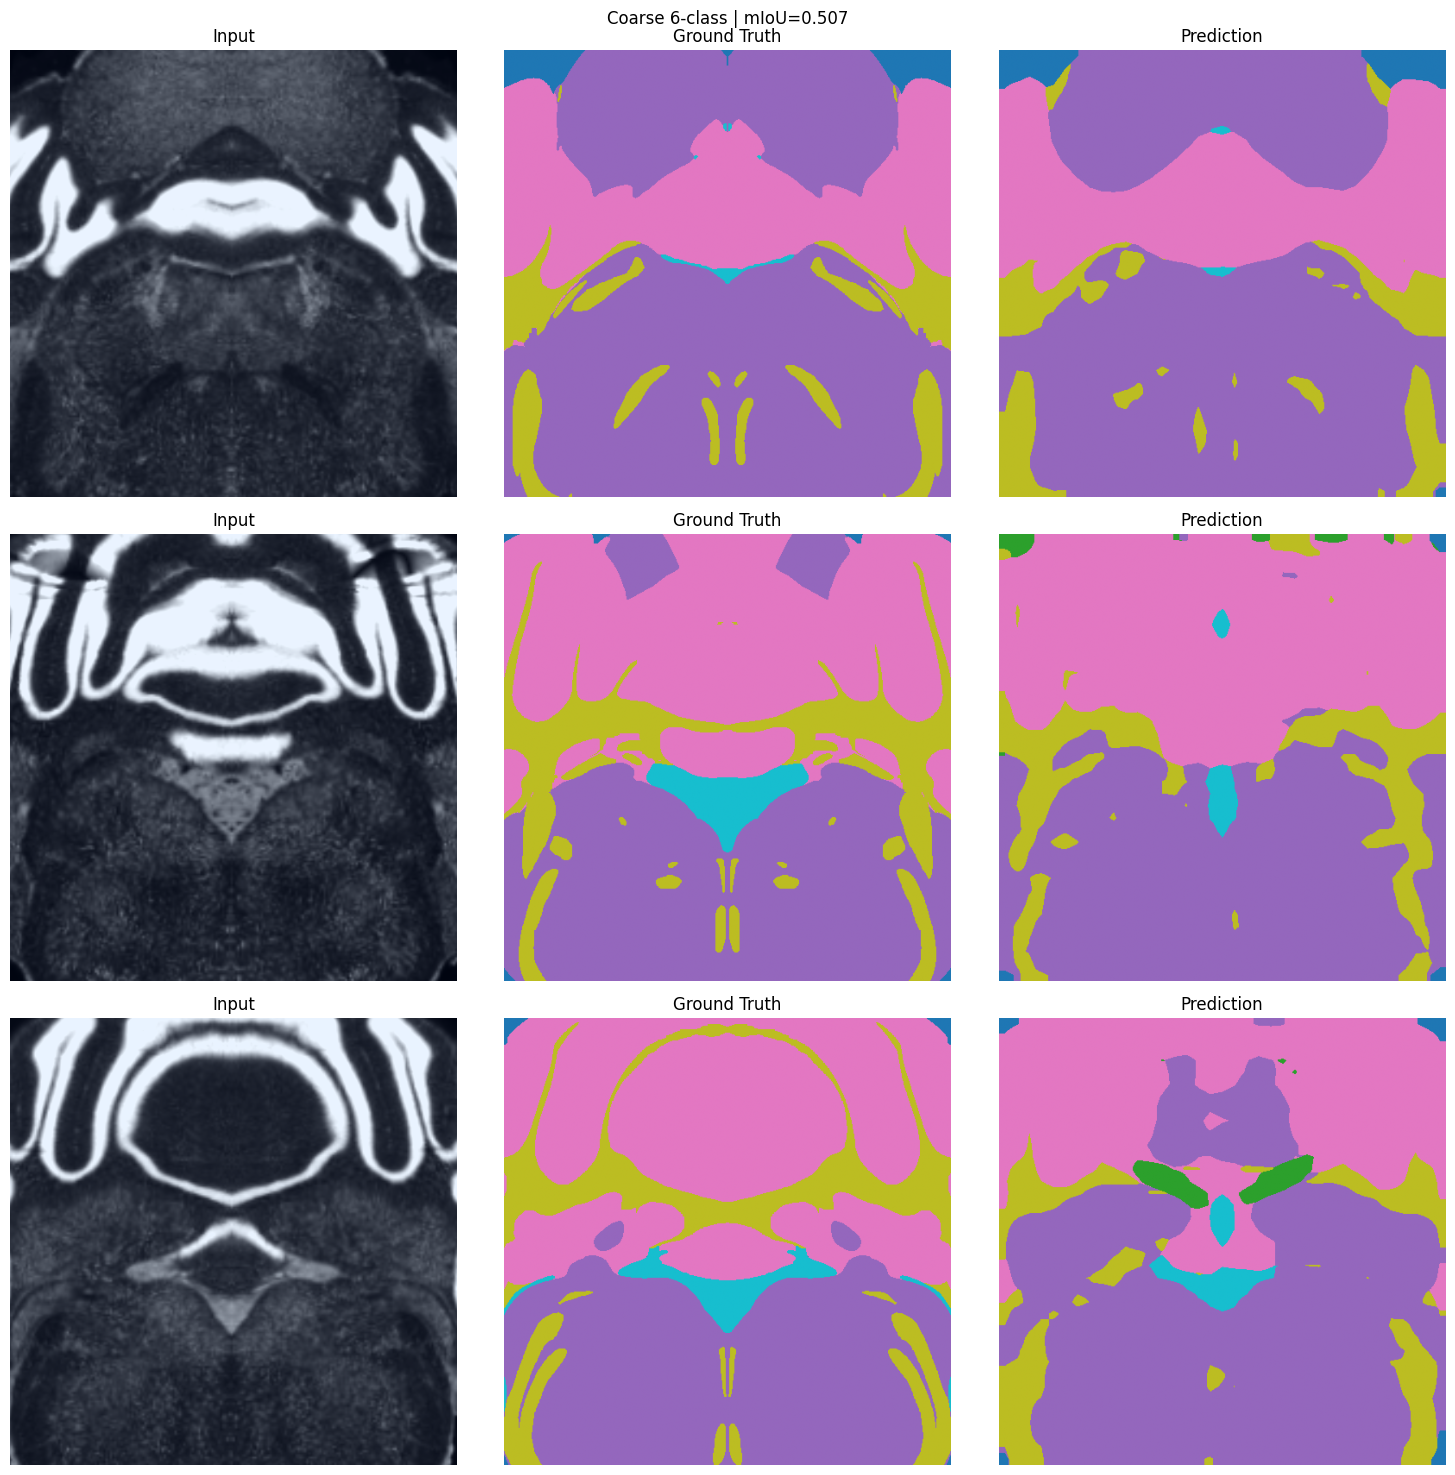

In [0]:
# Cell 6 — Evaluate + Visualize
#
# Logs to the same active MLflow run opened in Cell 5.

import matplotlib.pyplot as plt
import numpy as np

# Run evaluation
eval_results = trainer.evaluate()
print("Evaluation results:")
for k, v in sorted(eval_results.items()):
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

# Log final eval metrics explicitly (Trainer callback may use different keys)
mlflow.log_metrics({
    "final_mean_iou": eval_results.get("eval_mean_iou", 0.0),
    "final_overall_accuracy": eval_results.get("eval_overall_accuracy", 0.0),
})

# Visualize predictions vs ground truth on a few val samples
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    sample = val_ds[i * (len(val_ds) // 3)]
    pixel_values = sample["pixel_values"].unsqueeze(0)
    labels = sample["labels"].numpy()

    with torch.no_grad():
        if torch.cuda.is_available():
            pixel_values = pixel_values.cuda()
        logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Denormalize image for display
    img = sample["pixel_values"].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input")
    axes[i, 1].imshow(labels, cmap="tab10", vmin=0, vmax=NUM_LABELS - 1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(preds, cmap="tab10", vmin=0, vmax=NUM_LABELS - 1)
    axes[i, 2].set_title("Prediction")

for ax in axes.ravel():
    ax.axis("off")

plt.suptitle(f"Coarse {NUM_LABELS}-class | mIoU={eval_results.get('eval_mean_iou', 0):.3f}")
plt.tight_layout()
plt.show()

In [0]:
# Cell 7 — Save final model + close MLflow run

import os

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
trainer.save_model(FINAL_MODEL_DIR)
print(f"Model saved to: {FINAL_MODEL_DIR}")

# Close the MLflow run opened in Cell 5.
# Per LESSONS_LEARNED.md: HF Trainer's MLflowCallback can leave runs open.
mlflow.end_run()
print("MLflow run closed.")

Model saved to: /dbfs/FileStore/allen_brain_data/models/coarse_6class


2026/03/10 14:56:33 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/10 14:56:33 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


MLflow run closed.
